In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")

# Carregar dados
df = pd.read_csv("../metricas.csv")
if "tempo_ms" in df.columns:
    df.rename(columns={"tempo_ms": "tempo"}, inplace=True)

# Mapeamentos
map_metodos = {
    0: "Bisseção", 1: "Newton", 2: "Ponto Fixo",
    3: "Secante", 4: "Falsa Posição", 5: "Método 1 (Híbrido)"
}
map_funcoes = {
    0: "f1 (Grau 4)", 1: "f2 (Grau 5)", 2: "f3 (Exp/Trig)", 3: "f4 (x·sin(x) + 4)",
}

df["metodo_nome"] = df["id_metodo"].map(map_metodos)
df["funcao_nome"] = df["id_funcao"].map(map_funcoes)
df_conv = df[df["convergiu"] == 1].copy()

df.head()

,id_funcao,id_metodo,id_raiz,repeticao,a,b,tempo,iteracoes,convergiu,metodo_nome,funcao_nome
0,0,0,0,0,-2.0,-1.0,0.000004,22,1,Bisseção,f1 (Grau 4)
1,0,0,0,1,-2.0,-1.0,0.000003,22,1,Bisseção,f1 (Grau 4)
2,0,0,0,2,-2.0,-1.0,0.000003,22,1,Bisseção,f1 (Grau 4)
3,0,0,0,3,-2.0,-1.0,0.000003,22,1,Bisseção,f1 (Grau 4)
4,0,0,0,4,-2.0,-1.0,0.000003,22,1,Bisseção,f1 (Grau 4)


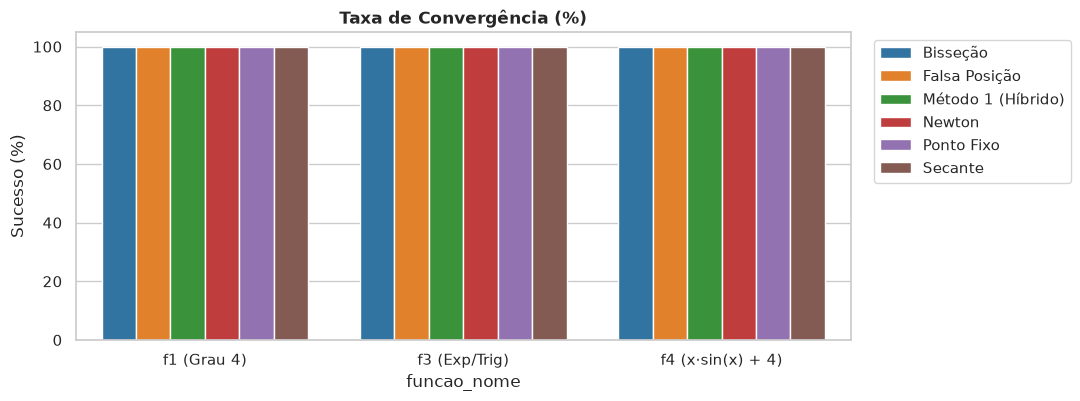

In [5]:
plt.figure(figsize=(10, 4))
taxa = df.groupby(["metodo_nome", "funcao_nome"])["convergiu"].mean().reset_index()
taxa["convergiu"] *= 100

sns.barplot(data=taxa, x="funcao_nome", y="convergiu", hue="metodo_nome")
plt.title("Taxa de Convergência (%)", fontweight="bold")
plt.ylabel("Sucesso (%)")
plt.ylim(0, 105)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

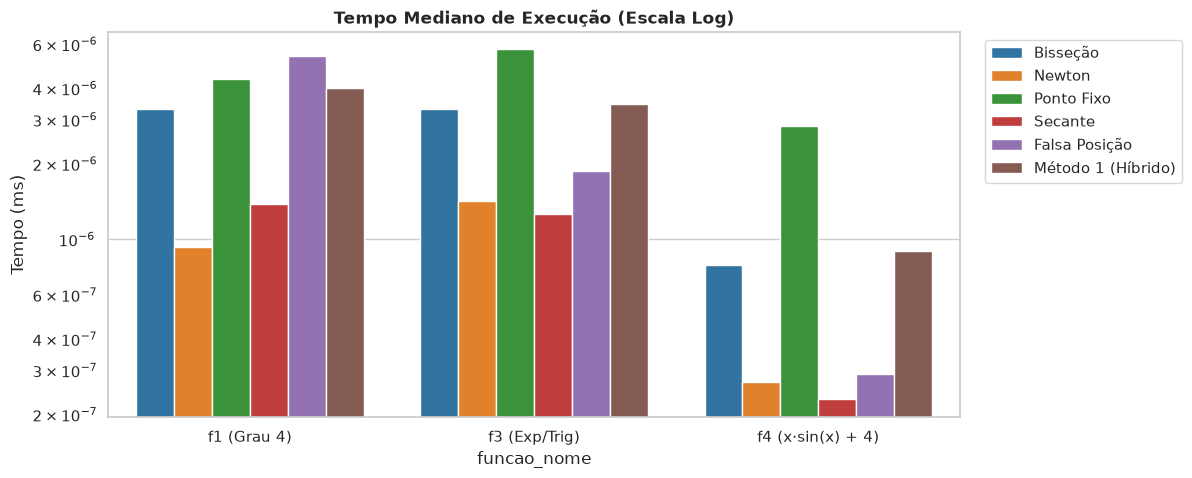

In [6]:
plt.figure(figsize=(11, 5))
sns.barplot(data=df_conv, x="funcao_nome", y="tempo", hue="metodo_nome", estimator="median", errorbar=None)
plt.title("Tempo Mediano de Execução (Escala Log)", fontweight="bold")
plt.ylabel("Tempo (ms)")
plt.yscale("log")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [7]:
df.groupby("metodo_nome")[["tempo", "iteracoes", "convergiu"]].agg(
    tempo_medio=("tempo", "mean"),
    iteracoes_medianas=("iteracoes", "median"),
    taxa_sucesso=("convergiu", lambda x: f"{x.mean()*100:.1f}%")
).sort_values("iteracoes_medianas")

,tempo_medio,iteracoes_medianas,taxa_sucesso
metodo_nome,,,
Falsa Posição,3.300026e-07,3.0,100.0%
Newton,2.790428e-07,3.0,100.0%
Secante,2.458200e-07,4.0,100.0%
Bisseção,8.635696e-07,26.0,100.0%
Método 1 (Híbrido),9.715759e-07,26.0,100.0%
Ponto Fixo,2.954472e-06,56.0,100.0%
